In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.xception import Xception, preprocess_input, decode_predictions

%matplotlib inline

In [2]:
## Loading the Images
path = './clothing-dataset-small-master/train/t-shirt'
name = 'fa53d8bd-0c11-4849-bd90-0eb6737f63a2.jpg'
fullname = f'{path}/{name}'
fullname

'./clothing-dataset-small-master/train/t-shirt/fa53d8bd-0c11-4849-bd90-0eb6737f63a2.jpg'

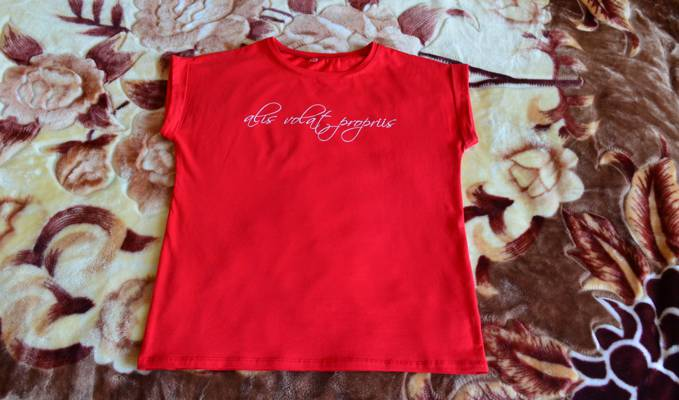

In [3]:
load_img(fullname)

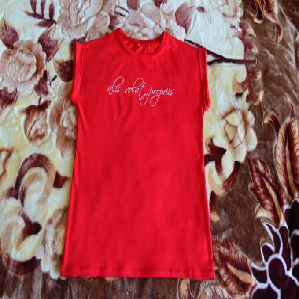

In [4]:
img = load_img(fullname, target_size=(299,299))
img

In [5]:
x = np.array(img)
x

array([[[188, 200, 198],
        [186, 198, 194],
        [187, 200, 193],
        ...,
        [ 63,  32,  14],
        [ 67,  36,  18],
        [ 73,  42,  24]],

       [[187, 199, 195],
        [183, 196, 189],
        [181, 194, 187],
        ...,
        [ 53,  21,   6],
        [ 48,  16,   1],
        [ 57,  25,  10]],

       [[183, 196, 189],
        [181, 194, 187],
        [180, 193, 186],
        ...,
        [ 48,  16,   1],
        [ 45,  13,   0],
        [ 52,  20,   5]],

       ...,

       [[ 64,  38,  39],
        [ 60,  35,  38],
        [ 91,  69,  71],
        ...,
        [ 21,   6,  13],
        [ 19,   4,  11],
        [ 15,   2,   9]],

       [[ 66,  42,  42],
        [ 75,  53,  55],
        [118,  98,  99],
        ...,
        [ 22,   5,  13],
        [ 18,   3,  10],
        [ 17,   2,   9]],

       [[121,  99, 101],
        [148, 128, 129],
        [160, 144, 145],
        ...,
        [ 23,   3,  12],
        [ 19,   2,  10],
        [ 17,   0,   8]]

In [6]:
x.shape

(299, 299, 3)

In [7]:
x[149][0][0], x[149][0][1], x[149][0][2]

(np.uint8(150), np.uint8(105), np.uint8(72))

In [8]:
## Pre-trained models
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

In [9]:
type(model)

keras.src.models.functional.Functional

In [10]:
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [11]:
X = preprocess_input(X)

In [12]:
type(X)

numpy.ndarray

In [13]:
pred = model.predict(X)
type(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step


numpy.ndarray

In [14]:
decode_predictions(pred)

[[('n03595614', 'jersey', np.float32(0.5986502)),
  ('n02730930', 'apron', np.float32(0.16866213)),
  ('n03710637', 'maillot', np.float32(0.025778275)),
  ('n04525038', 'velvet', np.float32(0.02010187)),
  ('n03877472', 'pajama', np.float32(0.015027166))]]

In [15]:
## ConvNN / CNN
# filter/kernel
# convolutional layer(intermediate layer + activation layer), pooling layer, fully connected layer/dense layer/flatten layer
# convolutional layer create feature map from the filters
# each conv layer learns unique feature
# conv layer extract the features and the vector representation while dense layer make predictions from the vector representation
# for binary classification, we use sigmoid function to predict while for multiple classification we use softmax
# use of pooling later: reduces the parameters and overall computation of the network, more computationally efficient and avoids overfitting

In [16]:
'''
Non-linearity is necessary to produce non-linear decision boundaries,
so that the output cannot be written as a linear combination of the inputs.
If a non-linear activation function was not present, 
deep CNN architectures would devolve into a single, equivalent convolutional layer, which would not perform nearly as well.
The ReLU activation function is specifically used as a non-linear activation function,
as opposed to other non-linear functions such as Sigmoid 
because it has been empirically observed that CNNs using ReLU are faster to train than their counterparts.
'''

'\nNon-linearity is necessary to produce non-linear decision boundaries,\nso that the output cannot be written as a linear combination of the inputs.\nIf a non-linear activation function was not present, \ndeep CNN architectures would devolve into a single, equivalent convolutional layer, which would not perform nearly as well.\nThe ReLU activation function is specifically used as a non-linear activation function,\nas opposed to other non-linear functions such as Sigmoid \nbecause it has been empirically observed that CNNs using ReLU are faster to train than their counterparts.\n'

In [17]:
## Transfer Learning
# conv layers are fixed while dense layers are modified
# dense layers are specific to the pre-trained models, hence needs to be changed
# 

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [19]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small-master/train',
    target_size=(150, 150),
    batch_size=32)

Found 3068 images belonging to 10 classes.


In [20]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [21]:
type(train_gen), type(train_ds)

(keras.src.legacy.preprocessing.image.ImageDataGenerator,
 keras.src.legacy.preprocessing.image.DirectoryIterator)

In [22]:
X, y = next(train_ds)
X.shape

(32, 150, 150, 3)

In [23]:
X

array([[[[ 0.5058824 , -0.6       , -0.5529412 ],
         [ 0.5058824 , -0.6       , -0.5529412 ],
         [ 0.5058824 , -0.6       , -0.5529412 ],
         ...,
         [-0.09803921, -0.67058825, -0.6       ],
         [-0.11372548, -0.42745095, -0.41960782],
         [-0.05098039, -0.23921567, -0.25490195]],

        [[ 0.5294118 , -0.5764706 , -0.5294118 ],
         [ 0.5294118 , -0.5764706 , -0.5294118 ],
         [ 0.5294118 , -0.5764706 , -0.5294118 ],
         ...,
         [ 0.254902  , -0.67058825, -0.5764706 ],
         [ 0.13725495, -0.6784314 , -0.5921569 ],
         [ 0.06666672, -0.6862745 , -0.6       ]],

        [[ 0.5294118 , -0.5764706 , -0.5294118 ],
         [ 0.5294118 , -0.5764706 , -0.5294118 ],
         [ 0.5294118 , -0.5764706 , -0.5294118 ],
         ...,
         [ 0.3176471 , -0.6627451 , -0.6       ],
         [ 0.27843142, -0.69411767, -0.6156863 ],
         [ 0.24705887, -0.7019608 , -0.6313726 ]],

        ...,

        [[ 0.7254902 , -0.05098039, -0

In [24]:
y.shape

(32, 10)

In [25]:
y[0]

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.], dtype=float32)

In [26]:
# validation data gen and set
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_ds = train_gen.flow_from_directory(
    './clothing-dataset-small-master/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [27]:
# input image is at bottom, dense layer is at top

In [28]:
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

base_model.trainable = False

In [29]:
inputs = keras.Input(shape=(150,150,3))
base = base_model(inputs) # base is the output of the base_model
pooling = keras.layers.GlobalAveragePooling2D()
vectors = pooling(base)
outputs = keras.layers.Dense(10)(vectors)
model = keras.Model(inputs, outputs) # training and creating a new model using keras

In [30]:
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 979ms/step


In [31]:
preds

array([[ 2.56286442e-01,  1.50804907e-01,  2.05524281e-01,
         8.23592603e-01,  4.02075529e-01,  1.39041534e-02,
        -9.67135549e-01,  7.67223418e-01, -1.23251581e+00,
        -6.16810739e-01],
       [ 6.69203401e-01, -7.18121588e-01,  4.58319873e-01,
         1.01480258e+00,  6.27888590e-02,  1.07104826e+00,
         8.12332630e-01,  1.64349794e-01, -1.29878950e+00,
        -1.12619662e+00],
       [ 8.99358928e-01, -1.53378856e+00, -1.27043939e+00,
         1.64523810e-01,  4.21287119e-01, -2.76656032e-01,
        -3.96546662e-01, -1.76982164e-01, -8.99450243e-01,
        -8.45114648e-01],
       [ 3.67356777e-01, -1.39786673e+00,  7.30589256e-02,
         1.57700253e+00, -2.12316185e-01,  8.63793939e-02,
        -4.71340507e-01, -1.71957374e-01, -5.03966093e-01,
        -9.90736127e-01],
       [ 4.29393202e-01, -1.42101610e+00, -2.88416058e-01,
         9.23759699e-01,  1.02582610e+00,  1.63623109e-01,
         3.37510020e-01,  2.68577546e-01,  2.94897199e-01,
        -6.

In [32]:
preds.shape # 32 1d vectors

(32, 10)

In [33]:
preds[0] # probabilities

array([ 0.25628644,  0.1508049 ,  0.20552428,  0.8235926 ,  0.40207553,
        0.01390415, -0.96713555,  0.7672234 , -1.2325158 , -0.61681074],
      dtype=float32)

In [34]:
# to train a CNN model, we need Optimizers
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.CategoricalCrossentropy(
    from_logits=True # adds probability(softmax), numerically stable, for tensors
)

In [35]:
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [36]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 42s 417ms/step - accuracy: 0.6551 - loss: 1.3095 - val_accuracy: 0.7771 - val_loss: 0.7987
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 427ms/step - accuracy: 0.8263 - loss: 0.5279 - val_accuracy: 0.7977 - val_loss: 0.8183
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 46s 483ms/step - accuracy: 0.8784 - loss: 0.3512 - val_accuracy: 0.7771 - val_loss: 0.9297
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 48s 497ms/step - accuracy: 0.8947 - loss: 0.2933 - val_accuracy: 0.7889 - val_loss: 0.8730
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 46s 481ms/step - accuracy: 0.9319 - loss: 0.1799 - val_accuracy: 0.7801 - val_loss: 0.9471
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 38s 399ms/step - accuracy: 0.9645 - loss: 0.1041 - val_accuracy: 0.7918 - val_loss: 0.8896
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 427ms/step - accuracy: 0.9804 - loss: 0.0661 - val_accuracy: 0.7977 - val_loss: 0.8611
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 44s 457ms/step - accuracy: 0.9840 - loss: 0.0582 - val_accu

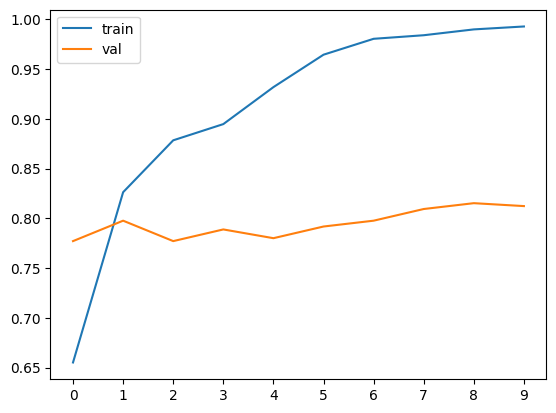

In [37]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()

In [38]:
# Adjusting the learning rate
# higher lr -> overfitting
# lower lr -> underfitting
# 

In [39]:
'''
Visualizing the training and validation accuracies help us to determine which learning rate value is the best for for the model.
One typical way to determine the best value is by looking at the gap between training and validation accuracy.
The smaller gap indicates the optimal value of the learning rate.
'''

'\nVisualizing the training and validation accuracies help us to determine which learning rate value is the best for for the model.\nOne typical way to determine the best value is by looking at the gap between training and validation accuracy.\nThe smaller gap indicates the optimal value of the learning rate.\n'

In [40]:
def make_model(learning_rate=0.01):
    base_model = Xception(weights='imagenet',
                          include_top=False,
                          input_shape=(150,150,3))

    base_model.trainable = False
    
    #########################################
    
    inputs = keras.Input(shape=(150,150,3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs, outputs)
    
    #########################################
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    # Compile the model
    model.compile(optimizer=optimizer,
                  loss=loss,
                  metrics=['accuracy'])
    
    return model

In [41]:
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(f'learning rate: {lr}')

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

learning rate: 0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 43s 431ms/step - accuracy: 0.3435 - loss: 1.9475 - val_accuracy: 0.5367 - val_loss: 1.5119
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 45s 472ms/step - accuracy: 0.5629 - loss: 1.3902 - val_accuracy: 0.6745 - val_loss: 1.1822
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 50s 521ms/step - accuracy: 0.6375 - loss: 1.1505 - val_accuracy: 0.7155 - val_loss: 1.0146
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 53s 557ms/step - accuracy: 0.6816 - loss: 1.0104 - val_accuracy: 0.7537 - val_loss: 0.9106
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 45s 464ms/step - accuracy: 0.7037 - loss: 0.9156 - val_accuracy: 0.7537 - val_loss: 0.8411
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 421ms/step - accuracy: 0.7288 - loss: 0.8466 - val_accuracy: 0.7654 - val_loss: 0.7941
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 423ms/step - accuracy: 0.7477 - loss: 0.7935 - val_accuracy: 0.7918 - val_loss: 0.7529
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 44s 462ms/step - accuracy: 0.7595 - l

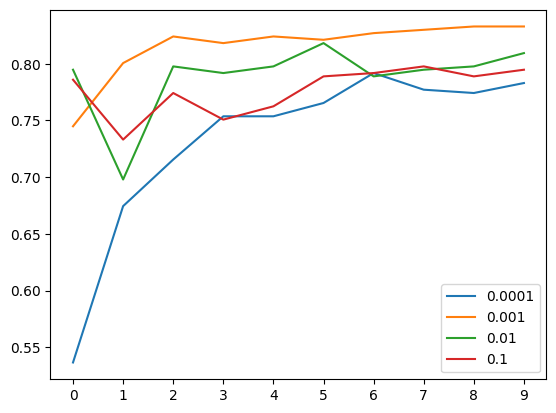

In [42]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=lr)
plt.xticks(np.arange(10))
plt.legend()

In [46]:
# 0.001 is the best
# check the gap between train accuracy and val accuracy
# 0.001 has the smaller gap

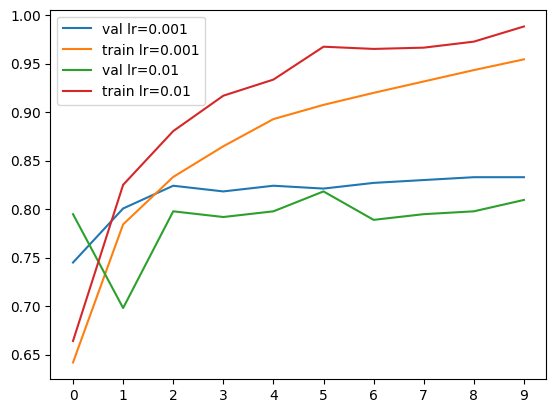

In [45]:
for lr, hist in scores.items():
    if lr in [0.001, 0.01]:
        plt.plot(hist['val_accuracy'], label=f'val lr={lr}')
        plt.plot(hist['accuracy'], label=f'train lr={lr}')
plt.xticks(np.arange(10))
plt.legend()

In [47]:
'xception_v1_{epoch:02d}_{val_acc:.3f}.hf'.format(epoch=3, val_acc=0.84)

'xception_v1_03_0.840.hf'

In [53]:
## Checkpointing
model.save('model_v1.keras')
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [55]:
learning_rate = 0.001
model = make_model(learning_rate=learning_rate)
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 45s 453ms/step - accuracy: 0.6294 - loss: 1.1160 - val_accuracy: 0.7625 - val_loss: 0.7270
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 47s 488ms/step - accuracy: 0.7819 - loss: 0.6332 - val_accuracy: 0.8035 - val_loss: 0.6054
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 47s 489ms/step - accuracy: 0.8308 - loss: 0.5037 - val_accuracy: 0.8035 - val_loss: 0.5941
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 54s 559ms/step - accuracy: 0.8621 - loss: 0.4302 - val_accuracy: 0.8182 - val_loss: 0.5608
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 50s 519ms/step - accuracy: 0.8895 - loss: 0.3675 - val_accuracy: 0.8094 - val_loss: 0.5615
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 573ms/step - accuracy: 0.9074 - loss: 0.3275 - val_accuracy: 0.8035 - val_loss: 0.5622
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 47s 484ms/step - accuracy: 0.9201 - loss: 0.2901 - val_accuracy: 0.8182 - val_loss: 0.5474
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 46s 475ms/step - accuracy: 0.9306 - loss: 0.2608 - val_accu

In [ ]:
## Adding more layers
# It is also possible to add more layers between the vector representation layer
# and the output layer to perform intermediate processing of the vector representation.
# These layers are the same dense layers as the output 
# but the difference is that these layers use relu activation function for non-linearity.

# Note: It may not always be possible that the model improves. 
# Adding more layers mean introducing complexity in the model, which may not be recommended in some cases.

In [56]:
# Function to define model by adding a new dense layer
def make_model(learning_rate=0.01, size_inner=100): # default layer size is 100
    base_model = Xception(weights='imagenet',
                          include_top=False,
                          input_shape=(150,150,3)
    )

    base_model.trainable = False
    
    #########################################
    
    inputs = keras.Input(shape=(150,150,3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors) # activation function 'relu'
    outputs = keras.layers.Dense(10)(inner)
    model = keras.Model(inputs, outputs)
    
    #########################################
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    # Compile the model
    model.compile(optimizer=optimizer,
                  loss=loss,
                  metrics=['accuracy']
    )
    
    return model

In [57]:
# Experiement different number of inner layer with best learning rate
# Note: We should've added the checkpoint for training but for simplicity we are skipping it
learning_rate = 0.001

scores = {}

# List of inner layer sizes
sizes = [10, 100, 1000]

for size in sizes:
    print(size)
    
    model = make_model(learning_rate=learning_rate, size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history
    
    print()
    print()

10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 44s 432ms/step - accuracy: 0.5492 - loss: 1.4009 - val_accuracy: 0.6716 - val_loss: 0.9909
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 43s 445ms/step - accuracy: 0.7073 - loss: 0.8754 - val_accuracy: 0.7126 - val_loss: 0.8182
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 43s 444ms/step - accuracy: 0.7842 - loss: 0.6685 - val_accuracy: 0.7859 - val_loss: 0.7005
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 50s 523ms/step - accuracy: 0.8201 - loss: 0.5570 - val_accuracy: 0.8035 - val_loss: 0.6509
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 575ms/step - accuracy: 0.8471 - loss: 0.4727 - val_accuracy: 0.8152 - val_loss: 0.6006
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 50s 519ms/step - accuracy: 0.8801 - loss: 0.4131 - val_accuracy: 0.8065 - val_loss: 0.5841
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 42s 442ms/step - accuracy: 0.9019 - loss: 0.3584 - val_accuracy: 0.8240 - val_loss: 0.5796
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 50s 519ms/step - accuracy: 0.9081 - loss: 0.3192 - val_a

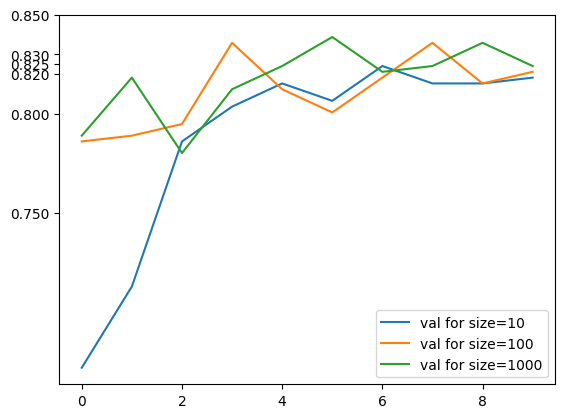

In [61]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val for size={size}')
plt.yticks([0.75, 0.80, 0.82, 0.825, 0.83, 0.85])
plt.legend()

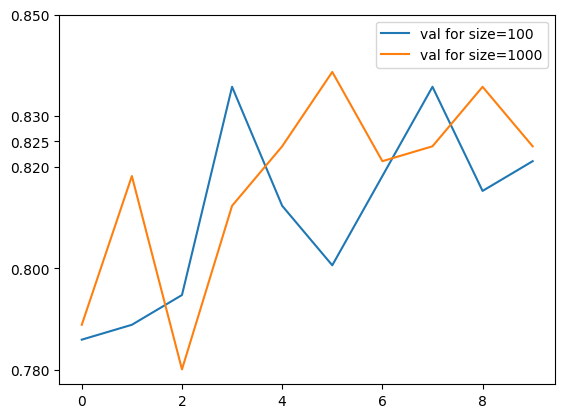

In [65]:
# size=10 discarded
for size, hist in scores.items():
    if size in [100, 1000]:
        plt.plot(hist['val_accuracy'], label=f'val for size={size}')
plt.yticks([0.78, 0.80, 0.82, 0.825, 0.83, 0.85])
plt.legend()
# 100 is selected as best

In [70]:
## Regularization & Dropout
# Dropout is a technique that prevents overfitting in neural networks by randomly dropping nodes of a layer during training.
# As a result, the trained model works as an ensemble model consisting of multiple neural networks.

# If there is a special sign like a logo, the model recognize it and tend to declare everything as t-shirt that has that logo.
# That means the model could make many mistakes in classification in validation data. 
# That leads to a worse generalization capability. 
# Instead the model should look at more general things like shapes instead of specific details.

# in dropout we’re not really hiding a part of the image but a part of the input. That means it applies the idea to inner layers.

# Note: Because we introduce dropout in the neural networks, we will need to train our model for longer,
# hence, number of epochs is set to 30.

In [73]:
#  neural network might learn false patterns,
# i.e. if it repeatedly recognizes a certain logo on a t-shirt it might learn that the logo defines the t-shirt 
# which is wrong since the logo might also be seen on a hoodie.

# hiding parts of the images (freeze) from being seen by the learning neural network
# dropout = randomly freezing parts of the image

In [72]:
# Regularization means that we introduce something that doesn’t let the neural network overfit to some patterns that might not exist.
# droprate=0.5 means that in each iteration we freeze 50% of this layer. Dropout keeps the dimensionality of the layer.

In [74]:
# Function to define model by adding a new dense layer and dropout
def make_model(learning_rate=0.01, size_inner=100, droprate=0.5): # default layer size is 100
    base_model = Xception(weights='imagenet',
                          include_top=False,
                          input_shape=(150,150,3)
    )

    base_model.trainable = False
    
    #########################################
    
    inputs = keras.Input(shape=(150,150,3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors) # activation function 'relu'
    drop = keras.layers.Dropout(droprate)(inner)
    outputs = keras.layers.Dense(10)(drop)
    model = keras.Model(inputs, outputs)
    
    #########################################
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    # Compile the model
    model.compile(optimizer=optimizer,
                  loss=loss,
                  metrics=['accuracy']
    )
    
    return model

In [76]:
# Create checkpoint to save best model for version 3
filepath = './xception_v3_{epoch:02d}_{val_accuracy:.3f}.keras'
checkpoint = keras.callbacks.ModelCheckpoint(filepath=filepath,
                                             save_best_only=True,
                                             monitor='val_accuracy',
                                             mode='max'
             )

# Set the best values of learning rate and inner layer size based on previous experiments
learning_rate = 0.001
size = 100

# Dict to store results
scores = {}

# List of dropout rates
droprates = [0.0, 0.2, 0.5, 0.8]

for droprate in droprates:
    print(f'droprate={droprate}')
    
    model = make_model(learning_rate=learning_rate,
                       size_inner=size,
                       droprate=droprate
    )
    
    # Train for longer (epochs=30) cause of dropout regularization
    history = model.fit(train_ds, epochs=30, validation_data=val_ds, callbacks=[checkpoint])
    scores[droprate] = history.history
    
    print()
    print()

droprate=0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 47s 469ms/step - accuracy: 0.6695 - loss: 0.9628 - val_accuracy: 0.7771 - val_loss: 0.6693
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 47s 489ms/step - accuracy: 0.8227 - loss: 0.5043 - val_accuracy: 0.8094 - val_loss: 0.5718
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 48s 500ms/step - accuracy: 0.8814 - loss: 0.3555 - val_accuracy: 0.8065 - val_loss: 0.5670
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 52s 546ms/step - accuracy: 0.9289 - loss: 0.2442 - val_accuracy: 0.8299 - val_loss: 0.5458
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 54s 568ms/step - accuracy: 0.9505 - loss: 0.1746 - val_accuracy: 0.8123 - val_loss: 0.5802
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 44s 462ms/step - accuracy: 0.9690 - loss: 0.1335 - val_accuracy: 0.8094 - val_loss: 0.5748
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 47s 485ms/step - accuracy: 0.9866 - loss: 0.0836 - val_accuracy: 0.8182 - val_loss: 0.6590
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 48s 497ms/step - accuracy: 0.9919 - loss: 0.06

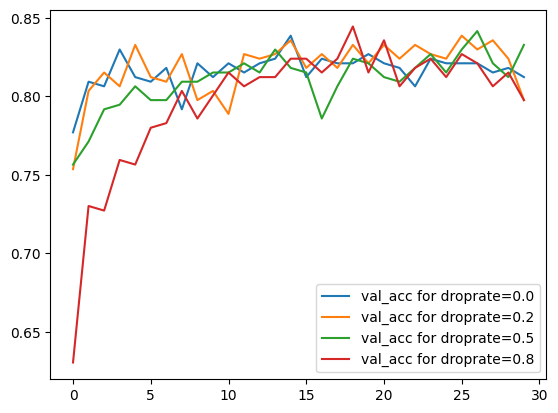

In [77]:
for droprate, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_acc for droprate={droprate}')
# plt.yticks([0.78, 0.80, 0.82, 0.825, 0.83, 0.85])
plt.legend()

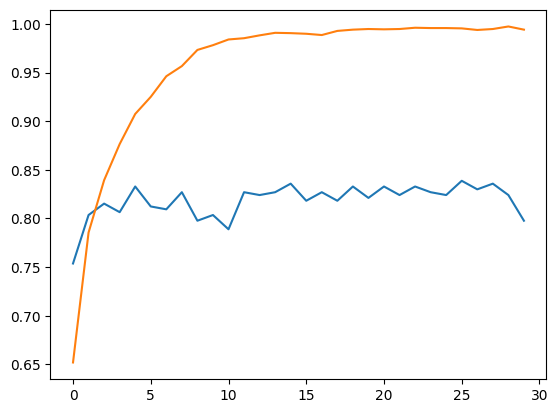

In [79]:
# analyze the best droprate : 0.2
hist = scores[0.2]
plt.plot(hist['val_accuracy'], label=f'val_acc for droprate={droprate}')
plt.plot(hist['accuracy'], label=f'train_acc for droprate={droprate}')